Make the 2D redshift slice plots

In [125]:
import os
import sys
import glob
import numpy as np
from tqdm import trange
from astropy.io import fits
from astropy.table import Table, vstack
from astropy.convolution import convolve, Gaussian1DKernel
import astropy.units as u
import astropy.coordinates as coord
import matplotlib
import matplotlib.pyplot as plt
from astropy.table import Column
from tqdm import trange
import pandas as pd
import fitsio
from astropy.table import Table, vstack
from astropy import units as u
from astropy.coordinates import SkyCoord
from easyquery import Query, QueryMaker
from scipy.stats import binomtest
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm
import h5py
from astropy.cosmology import Planck18


import matplotlib as mpl

mpl.rcParams.update({
    # --- Fonts (your existing sizes + cmr10 serif from new style) ---
    'font.family':                 'serif',
    'font.serif':                  'cmr10',
    'font.size':                   11,
    'mathtext.fontset':            'cm',
    'axes.unicode_minus':          False,
    'axes.formatter.use_mathtext': True,
    'axes.labelsize':              12,
    'axes.titlesize':              12,
    'xtick.labelsize':             10,
    'ytick.labelsize':             10,
    'legend.fontsize':             11,

    # --- Axes ---
    'axes.linewidth':              1.0,
    'axes.xmargin':                0.05,

    # --- X ticks: in, all sides, minor ticks on ---
    'xtick.direction':             'in',
    'xtick.top':                   True,
    'xtick.minor.visible':         True,
    'xtick.major.top':             True,
    'xtick.minor.top':             True,
    'xtick.major.size':            3.5,
    'xtick.minor.size':            2.0,
    'xtick.major.width':           1.0,
    'xtick.minor.width':           0.8,
    'xtick.major.pad':             4,
    'xtick.minor.pad':             4,

    # --- Y ticks: in, all sides, minor ticks on ---
    'ytick.direction':             'in',
    'ytick.right':                 True,
    'ytick.minor.visible':         True,
    'ytick.major.right':           True,
    'ytick.minor.right':           True,
    'ytick.major.size':            3.5,
    'ytick.minor.size':            2.0,
    'ytick.major.width':           1.0,
    'ytick.minor.width':           0.8,
    'ytick.major.pad':             4,
    'ytick.minor.pad':             4,

    # --- Legend ---
    'legend.frameon':              False,
    'legend.edgecolor':            'k',
    'legend.framealpha':           0,

    # --- Figure / savefig / misc ---
    'figure.facecolor':            'w',
    'image.aspect':                'auto',
    'image.cmap':                  'magma',
    'savefig.format':              'pdf',
    'savefig.bbox':                'tight',
    'savefig.dpi':                 300,
    'savefig.transparent':         False,
    'errorbar.capsize':            0,
    'lines.markersize':            5,
    'hist.bins':                   'auto',
})

from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs
from desi_lowz_funcs import calc_normalized_dist
from desi_lowz_funcs import find_objects_nearby
# from construct_dwarf_galaxy_catalogs import process_sga_matches

# from consolidate_photometry import get_fastspec_fit_catalog_V2


%load_ext autoreload
%autoreload 2

MARGIN_LABEL  = 0.9   # edge with axis label + tick labels
MARGIN_TICKS  = 0.45  # edge with only tick labels (no axis label)
MARGIN_PAD    = 0.2   # edge with nothing
MARGIN_SHARED = 0.1   # gap between panels sharing an axis
MARGIN_SPLIT  = 0.7   # gap between panels with independent axes
MARGIN_CBAR   = 1.1   # edge with a colorbar

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))

from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs
from desi_lowz_funcs import calc_normalized_dist
from desi_lowz_funcs import find_objects_nearby
from construct_dwarf_galaxy_catalogs import process_sga_matches


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Make a slice plot focusing on the patch where DESI is really complete and do something there!

In [27]:

# Path to the catalog
filename = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"

# Option 1: load the MAIN extension directly as an Astropy Table
main = Table.read(filename, hdu="MAIN")

# Option 2: load the SPEC_DERIVED extension
fastspec = Table.read(filename, hdu="SPEC_DERIVED")


In [28]:
len(main)

461543

In [29]:
tot_cat = main.copy()

tot_cat = tot_cat[(tot_cat["DWARF_MASKBIT"] == 0) & (tot_cat["MSTAR_MASKBIT"] == 0)]

In [30]:
len(tot_cat)

397400

In [31]:
tot_cat["LOG_MSTAR_M24"].max()

9.249998092651367

## Make the slice plot!!

In [134]:

##make the DESI slice

dec_low = 0 - 5
dec_high = 0 + 5

slice_mask = (tot_cat["RA"] < 230) & (tot_cat["RA"] > 130) & (tot_cat["DEC"] > dec_low) & (tot_cat["DEC"] < dec_high) #& (tot_cat["Z"] < 0.2) 

tot_cat_slice = tot_cat[slice_mask]

##read in GAMA catalog
gama_cat = Table.read("/pscratch/sd/v/virajvm/catalog/gama_dwarf_cat.fits")

slice_mask_gama = (gama_cat["RAcen"] < 230) & (gama_cat["RAcen"] > 130) & (gama_cat["Deccen"] > dec_low) & (gama_cat["Deccen"] < dec_high) 

tot_cat_slice_gama = gama_cat[ slice_mask_gama ]

# gama_g12_mask = (tot_cat["RA"] < 186) & (tot_cat["RA"] > 174) & (tot_cat["DEC"] > -3) & (tot_cat["DEC"] < 2) & (tot_cat["Z"] < 0.2) & (tot_cat["MAG_R"] < 19.8)
# gama_g09_mask = (tot_cat["RA"] < 141) & (tot_cat["RA"] > 129) & (tot_cat["DEC"] > -2) & (tot_cat["DEC"] < 3) & (tot_cat["Z"] < 0.2) & (tot_cat["MAG_R"] < 19.8)
# gama_g15_mask = (tot_cat["RA"] < 223.5) & (tot_cat["RA"] > 211.5) & (tot_cat["DEC"] > -2) & (tot_cat["DEC"] < 3) & (tot_cat["Z"] < 0.2)   & (tot_cat["MAG_R"] < 19.8)
# tot_cat_slice_gama = tot_cat[  gama_g12_mask | gama_g15_mask | gama_g09_mask ]

tot_cat_slice_gama.rename_column("RAcen","RA")
tot_cat_slice_gama.rename_column("Deccen","DEC")

tot_cat_slice_gama["comov_dist"] = Planck18.comoving_distance(tot_cat_slice_gama["Z"]).data
###read in SDSS/NSA catalog

sdss_nsa_cat = Table.read("/pscratch/sd/v/virajvm/catalog/nsa_dwarf_catalog.fits")

slice_mask_sdss = (sdss_nsa_cat["RA"] < 230) & (sdss_nsa_cat["RA"] > 130) & (sdss_nsa_cat["DEC"] > dec_low) & (sdss_nsa_cat["DEC"] < dec_high) 

tot_cat_slice_sdss = sdss_nsa_cat[slice_mask_sdss ]

tot_cat_slice_sdss["comov_dist"] = Planck18.comoving_distance(tot_cat_slice_sdss["Z"]).data


(130.0, 230.0)

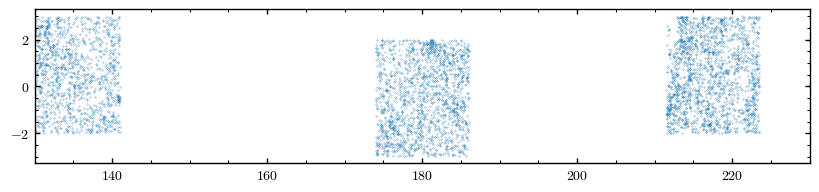

In [33]:
plt.figure(figsize = (10,2))
plt.scatter(tot_cat_slice_gama["RA"], tot_cat_slice_gama["DEC"],s=0.05)
plt.xlim([130,230])


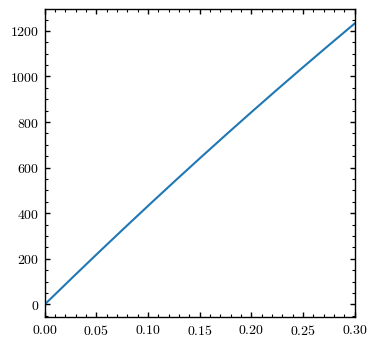

In [19]:
zmax = 0.3

zgrid = np.linspace(0.001,zmax,1000)

cmov_dist = Planck18.comoving_distance(zgrid)

from scipy.interpolate import UnivariateSpline

spl_z = UnivariateSpline( cmov_dist, zgrid, s=0.)

plt.figure(figsize = (4,4))
plt.plot(zgrid, cmov_dist)
plt.xlim([0,zmax])
plt.show()

In [34]:
from astropy.table import Table

# saga_gals = Table.read('https://sagasurvey.org/data/saga-dr3-tableC2.txt', format='ascii.mrt')
saga_gals = Table.read("/pscratch/sd/v/virajvm/catalog/saga_dr3_dwarf_cat.fits")
print(len(saga_gals))

saga_gals.rename_columns(["RAdeg", "DEdeg","z"], ["RA","DEC","Z"])

8954


In [35]:
##measure stellar mass in same way as we are measuring the other stellar masses

saga_slice_mask = (saga_gals["RA"] < 230) & (saga_gals["RA"] > 130) & (saga_gals["DEC"] < 5) & (saga_gals["DEC"] > -5) & (saga_gals["Z"] >0) & (saga_gals["Z"] < 0.3)

saga_gals_slice = saga_gals[saga_slice_mask]

print(len(saga_gals_slice))

saga_gals_slice["comov_dist"] = Planck18.comoving_distance(saga_gals_slice["Z"]).data


1500


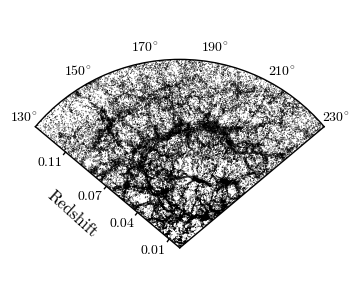

In [203]:
ra_ticks_vals = np.array([130,150, 170, 190, 210, 230])
ra_min = 130
ra_max = 230
pad_val =-15

fig, ax = plt.subplots(1,1,figsize = (3.75,3.75),subplot_kw={'projection': 'polar'})

### ALL GALAXIES IN NED-LVS
ra_radians = np.deg2rad(tot_cat_slice["RA"])
ax.scatter(ra_radians, tot_cat_slice["LUMI_DIST_MPC"], color = "k", alpha=0.6,s=0.5,
           rasterized=True, linewidths=0, edgecolors="none")

# Add labels and a colorbar
ax.set_theta_zero_location("S")  # Optional: sets 0° at the bottom (South)
ax.set_theta_direction(-1)       # Optional: clockwise direction for RA
# Set title and labels
ax.set_thetamin(ra_min)   # Min angle in degrees (start of the slice)
ax.set_thetamax(ra_max)
ax.set_rlim(0,600)

ax.set_rticks([ 44.20505558, 175.56757391, 305.02911976, 474.64670145])

ax.set_yticklabels([r"$0.01$","0.04","0.07","0.11"])

# Add the label using ax.text()
ax.text(np.deg2rad(108),        # angle in radians
        ax.get_rmax() * 0.6,   # just outside the outermost circle
        "Redshift",
        rotation=-42,
        ha='center',
        va='center',
       fontsize = 12)

ax.grid(ls = ":", color = "lightgrey",alpha = 0.5)

rtick_vals = [44.20505558, 175.56757391, 305.02911976, 474.64670145]
tick_len = 10  # in data units (radius units), tweak to taste

for theta_deg, direction in [(ra_min, -1)]:
    theta = np.deg2rad(theta_deg)
    for r in rtick_vals:
        dtheta = direction * tick_len / r
        ax.plot([theta, theta + dtheta], [r, r],
                color='k', lw=1, clip_on=False)

ra_ticks = np.deg2rad(ra_ticks_vals)
ax.set_xticks(ra_ticks)
ax.set_xticklabels([fr'${int(r)}\!^\circ$' for r in ra_ticks_vals])

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/desi_slice_plot.pdf",dpi=300)

plt.show()


In [166]:
Planck18.comoving_distance([0.01,0.04,0.07,0.11]).value

array([ 44.20505558, 175.56757391, 305.02911976, 474.64670145])

In [177]:
import cmasher as cmr
from matplotlib.lines import Line2D

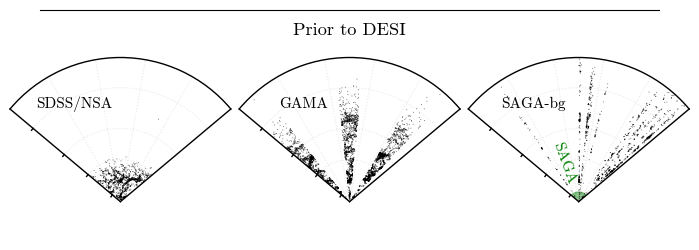

In [197]:
fig, axes = plt.subplots(1, 3, figsize=(2.5*2.75, 2.5),
                         subplot_kw={'projection': 'polar'},
                         constrained_layout=True)

fig.suptitle("Prior to DESI",y=0.93)
            # bbox=dict(boxstyle='round,pad=0.4',
            #            facecolor='white', edgecolor='k', lw=0.8))

line = Line2D([0.05, 0.95], [1.05-0.07, 1.05-0.07],
              color='k', lw=0.8,
              transform=fig.transFigure, figure=fig)
fig.add_artist(line)

rmax_val = 450
marker_size = 0.5

ra_radians = np.deg2rad(tot_cat_slice_sdss["RA"])
axes[0].scatter(ra_radians, tot_cat_slice_sdss["comov_dist"], color = "k", alpha=0.6,s=marker_size,
                rasterized=True, linewidths=0, edgecolors="none")

axes[0].text(np.deg2rad(155),        # angle in radians
        rmax_val,   # just outside the outermost circle
        "SDSS/NSA",
        color = "k",
        rotation=0,
        ha='center',
        va='center')

######

ra_radians = np.deg2rad(tot_cat_slice_gama["RA"])

axes[1].scatter(ra_radians, tot_cat_slice_gama["comov_dist"], color = "k", alpha=0.6,s=marker_size,
                rasterized=True, linewidths=0, edgecolors="none")

axes[1].text(np.deg2rad(155),        # angle in radians
        rmax_val,   # just outside the outermost circle
        "GAMA",
        color = "k",
        rotation=0,
        ha='center',
        va='center')

#####

ra_radians = np.deg2rad(saga_gals_slice["RA"])
axes[2].scatter(ra_radians, saga_gals_slice["comov_dist"], color = "k", alpha=0.6,s=marker_size,
                rasterized=True, linewidths=0, edgecolors="none")


# Parameters
r_max_shade = 40  # Up to what radius to shade
n_points = 500     # Resolution of the fill
theta1 = np.deg2rad(ra_min)
theta2 = np.deg2rad(ra_max)
theta = np.linspace(theta1, theta2, n_points)

# Create a filled sector
r_inner = np.zeros_like(theta)
r_outer = np.full_like(theta, r_max_shade)

# Fill from center to outer radius
axes[2].fill(np.concatenate([theta, theta[::-1]]),
        np.concatenate([r_inner, r_outer[::-1]]),
        color='green', alpha=0.5, zorder=0)

axes[2].text(np.deg2rad(160),        # angle in radians
        175,   # just outside the outermost circle
        "SAGA",
        color = "green",
        alpha = 1,
        rotation=-70,
        ha='center',
        va='center')


axes[2].text(np.deg2rad(155),        # angle in radians
        rmax_val,   # just outside the outermost circle
        "SAGA-bg",
        color = "k",
        rotation=0,
        ha='center',
        va='center')

for axi in axes:
    axi.set_theta_zero_location("S")  # Optional: sets 0° at the bottom (South)
    axi.set_theta_direction(-1)       # Optional: clockwise direction for RA
    # Set title and labels
    # ax.set_title('Galaxy Distribution by Redshift and RA')
    axi.set_thetamin(ra_min)   # Min angle in degrees (start of the slice)
    axi.set_thetamax(ra_max)
    axi.set_rlim(0,600)

    axi.tick_params(axis='x', pad=0)  # negative moves labels closer to the plot

    axi.set_rticks([ 44.20505558, 175.56757391, 305.02911976, 474.64670145])
    
    axi.set_yticklabels([r"","","",""])

    ra_ticks = np.deg2rad(ra_ticks_vals)
    
    axi.set_xticks(ra_ticks)
    axi.set_xticklabels([fr'' for r in ra_ticks_vals])
    
    axi.grid(ls = ":", color = "lightgrey",alpha = 0.5)
    
    rtick_vals = [44.20505558, 175.56757391, 305.02911976, 474.64670145]
    tick_len = 10  # in data units (radius units), tweak to taste
    
    for theta_deg, direction in [(ra_min, -1)]:
        theta = np.deg2rad(theta_deg)
        for r in rtick_vals:
            dtheta = direction * tick_len / r
            axi.plot([theta, theta + dtheta], [r, r],
                    color='k', lw=1, clip_on=False)

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/other_slice_plot.pdf",dpi=300)
    
plt.show()



In [204]:
print(len(tot_cat))

from catalog_paper_plots import get_density_map
from healpy.newvisufunc import projview


397400


In [205]:

area = 100*10

area_mask = (tot_cat["RA"] < 230) & (tot_cat["RA"] > 130) & (tot_cat["DEC"] < 5) & (tot_cat["DEC"] > -5)

bgsb_tgts = len( tot_cat[(tot_cat["SAMPLE"] == "BGS_BRIGHT") & area_mask ] )
bgsf_tgts = len( tot_cat[(tot_cat["SAMPLE"] == "BGS_FAINT") & area_mask] )
lowz_tgts = len( tot_cat[(tot_cat["SAMPLE"] == "LOWZ") & area_mask] )
elg_tgts = len( tot_cat[(tot_cat["SAMPLE"] == "ELG") & area_mask] )

print(f"BGS Bright density = {bgsb_tgts/area:.2f}")
print(f"BGS Faint density = {bgsf_tgts/area:.2f}")
print(f"LOWZ density = {lowz_tgts/area:.2f}")
print(f"ELG density = {elg_tgts/area:.2f}")

print(len(tot_cat))

BGS Bright density = 24.15
BGS Faint density = 10.96
LOWZ density = 16.58
ELG density = 31.37
397400


In [206]:
samples = ["BGS", "LOWZ", "ELG"]
mass_bins = [(6, 7), (7, 8), (8, 9), (9, 9.25)]

for sample in samples:
    if sample == "BGS":
        sample_mask = ((tot_cat["SAMPLE"] == "BGS_BRIGHT") | (tot_cat["SAMPLE"] == "BGS_FAINT")) & area_mask
    else:
        sample_mask = (tot_cat["SAMPLE"] == sample) & area_mask
    
    total = len(tot_cat[sample_mask])
    print(f"\n{sample}: total density = {total/area:.2f}")
    
    for lo, hi in mass_bins:
        mass_mask = sample_mask & (tot_cat["LOG_MSTAR_M24"] >= lo) & (tot_cat["LOG_MSTAR_M24"] < hi)
        count = len(tot_cat[mass_mask])
        print(f"  M* [{lo}-{hi}): {count/area:.2f}  (N={count}), (NTOTAL_DESI_Y5 = {round(1.1 * 14000 * count / area, -2):.0f})")


BGS: total density = 35.11
  M* [6-7): 0.07  (N=68), (NTOTAL_DESI_Y5 = 1000)
  M* [7-8): 1.11  (N=1113), (NTOTAL_DESI_Y5 = 17100)
  M* [8-9): 20.13  (N=20132), (NTOTAL_DESI_Y5 = 310000)
  M* [9-9.25): 13.80  (N=13798), (NTOTAL_DESI_Y5 = 212500)

LOWZ: total density = 16.58
  M* [6-7): 0.04  (N=41), (NTOTAL_DESI_Y5 = 600)
  M* [7-8): 0.97  (N=970), (NTOTAL_DESI_Y5 = 14900)
  M* [8-9): 11.01  (N=11008), (NTOTAL_DESI_Y5 = 169500)
  M* [9-9.25): 4.56  (N=4560), (NTOTAL_DESI_Y5 = 70200)

ELG: total density = 31.37
  M* [6-7): 0.17  (N=172), (NTOTAL_DESI_Y5 = 2600)
  M* [7-8): 9.55  (N=9552), (NTOTAL_DESI_Y5 = 147100)
  M* [8-9): 20.77  (N=20768), (NTOTAL_DESI_Y5 = 319800)
  M* [9-9.25): 0.87  (N=869), (NTOTAL_DESI_Y5 = 13400)


In [27]:
# 900+600+5000
# 15000+12000+140000
# 211000 +117000 + 424000
# 183000 + 67000 + 64000

print(900+15000 + 211000+183000 )
print(600 + 12000 + 117000 + 67000 )
print(5000 + 140000 + 424000 + 64000) 
print(6500 + 167000 + 752000 + 314000) 


409900
196600
633000
1239500


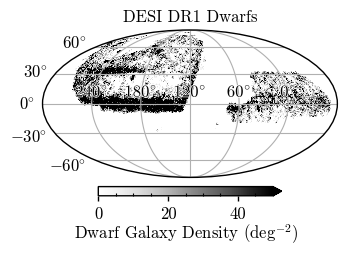

In [202]:
##let us compute the target sample specific target densities

density_map_64 = get_density_map(128, tot_cat["RA"].data, tot_cat["DEC"].data)

cmap = matplotlib.colormaps['Greys'].copy()
cmap.set_bad(color='white')

fontsize_dict = {"cbar_label":12, "cbar_tick_label":12}

ax = projview(
    density_map_64, min=0,max = 50,rot = (120, 0, 0), graticule=True, graticule_labels=True, projection_type="mollweide",
    nest=True,cmap = cmap,
    rot_graticule=False,width = 3.25,
    custom_xtick_labels=[r"$240^{\circ}$",r"$180^{\circ}$",r"$120^{\circ}$", r"$60^{\circ}$",r"$0^{\circ}$"],
    unit=r"Dwarf Galaxy Density (deg$^{-2}$)",cbar_ticks=[0,20,40],
    fontsize=fontsize_dict
)

##adding the rectangle 

# Define rectangle corners in RA/Dec
ra1, ra2 = 130 + 120, 230 + 120  # degrees
dec1, dec2 = -5, 5  # degrees

# Convert RA from [0,360] -> [-180,180] and then to radians
def ra_to_mollweide_radians(ra_deg):
    ra_wrapped = ((ra_deg + 180) % 360) - 180  # wrap into [-180, 180]
    return np.deg2rad(ra_wrapped)

# Convert Dec to radians directly
def dec_to_radians(dec_deg):
    return np.deg2rad(dec_deg)

# Get rectangle edges
ra_edges = [ra1, ra2, ra2, ra1, ra1]
dec_edges = [dec1, dec1, dec2, dec2, dec1]

x = ra_to_mollweide_radians(np.array(ra_edges))
y = dec_to_radians(np.array(dec_edges))

# Plot on the current axes (projview uses gca)
ax = plt.gca()
# ax.plot(x, y, color='r', lw=1,ls = "--",alpha=0.75)

yref = -20
shift = 12

import matplotlib.patheffects as pe

# Outline RA tick labels
for label in ax.get_xticklabels():
    label.set_color("black")
    label.set_path_effects([
        pe.Stroke(linewidth=1, foreground="white"),
        pe.Normal()
    ])


#######

ax.tick_params(
    axis="both",
    which="major",
)

ax.set_title(r"DESI DR1 Dwarfs")

ax.set_yticklabels([fr'${int(r)}\!^\circ$' for r in [-60,-30,0,30,60]])

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/dwarf_galaxy_density.pdf")

plt.show()


In [ ]:
18 + 8 + 13 + 41